# Dengue Fever ANN Predictor

A reproducible data science pipeline that loads DengAI competition data, performs exploratory data analysis, trains a Keras ANN, evaluates it, and produces a submission CSV and an academic report in Bahasa Indonesia.

## Environment Setup and Reproducibility Seeds

This section sets up the computing environment by importing all necessary libraries and setting random seeds to ensure full reproducibility of results across multiple runs.

In [1]:
import random
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
from math import sqrt

# Set reproducibility seeds before any data processing, splitting, or model training
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("Random seeds set: random.seed(42), np.random.seed(42), tf.random.set_seed(42)")
print("Environment setup complete.")

Random seeds set: random.seed(42), np.random.seed(42), tf.random.set_seed(42)
Environment setup complete.


### Python and Library Versions

The following cell documents the exact versions of Python and key libraries used in this pipeline for reproducibility purposes.

In [2]:
import sys
import sklearn

print(f"Python version: {sys.version}")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"matplotlib version: {plt.matplotlib.__version__}")

Python version: 3.11.1 (tags/v3.11.1:a7a450f, Dec  6 2022, 19:58:39) [MSC v.1934 64 bit (AMD64)]
pandas version: 2.3.3
numpy version: 2.1.3
scikit-learn version: 1.8.0
TensorFlow version: 2.21.0
seaborn version: 0.13.2
matplotlib version: 3.10.9


## Data Loading and Merging

This section loads the four CSV files from the DengAI competition dataset and merges the training features with labels using a left join on the shared key columns (city, year, weekofyear).

In [3]:
# Load the four CSV files from the data/ directory
df_features_train = pd.read_csv('data/dengue_features_train.csv')
df_labels_train = pd.read_csv('data/dengue_labels_train.csv')
df_test = pd.read_csv('data/dengue_features_test.csv')
df_submission = pd.read_csv('data/submission_format.csv')

# Left-join train features and labels on shared key columns
df_train_merged = pd.merge(
    df_features_train,
    df_labels_train,
    on=['city', 'year', 'weekofyear'],
    how='left'
)

# Print shapes to notebook output
print(f'df_train_merged shape: {df_train_merged.shape}')
print(f'df_test shape: {df_test.shape}')
print(f'df_submission shape: {df_submission.shape}')

df_train_merged shape: (1456, 25)
df_test shape: (416, 24)
df_submission shape: (416, 4)


## Missing Value Handling

This section applies a systematic imputation strategy to fill missing values: forward-fill, then backward-fill, then mean imputation for columns with 5 or more remaining NaN values, and finally zero-fill for any entirely-NaN columns.

In [4]:
def handle_missing_values(df, df_name='DataFrame'):
    """
    Handle missing values in a DataFrame using a multi-step imputation strategy:
    1. Forward-fill then backward-fill on all numeric columns
    2. Mean imputation if >= 5 NaN values remain in a column
    3. Fill with 0 and print warning if all values in a column are still NaN
    """
    numeric_cols = df.select_dtypes(include='number').columns
    
    for col in numeric_cols:
        # Step 1: Forward-fill then backward-fill
        df[col] = df[col].ffill().bfill()
        
        # Step 2: Mean imputation if >= 5 NaN values remain
        if df[col].isna().sum() >= 5:
            col_mean = df[col].mean()
            df[col] = df[col].fillna(col_mean)
        
        # Step 3: All-NaN guard — fill with 0 and print warning
        if df[col].isna().sum() > 0:
            df[col] = df[col].fillna(0)
            print(f"WARNING: column '{col}' in {df_name} is entirely NaN — filled with 0")
    
    return df

# Apply missing value handling to both DataFrames
df_train_merged = handle_missing_values(df_train_merged, 'df_train_merged')
df_test = handle_missing_values(df_test, 'df_test')

# Print DataFrame shapes and per-column null counts after imputation
print(f'\ndf_train_merged shape after imputation: {df_train_merged.shape}')
print(f'df_train_merged null counts per column:')
print(df_train_merged.isnull().sum())

print(f'\ndf_test shape after imputation: {df_test.shape}')
print(f'df_test null counts per column:')
print(df_test.isnull().sum())


df_train_merged shape after imputation: (1456, 25)
df_train_merged null counts per column:
city                                     0
year                                     0
weekofyear                               0
week_start_date                          0
ndvi_ne                                  0
ndvi_nw                                  0
ndvi_se                                  0
ndvi_sw                                  0
precipitation_amt_mm                     0
reanalysis_air_temp_k                    0
reanalysis_avg_temp_k                    0
reanalysis_dew_point_temp_k              0
reanalysis_max_air_temp_k                0
reanalysis_min_air_temp_k                0
reanalysis_precip_amt_kg_per_m2          0
reanalysis_relative_humidity_percent     0
reanalysis_sat_precip_amt_mm             0
reanalysis_specific_humidity_g_per_kg    0
reanalysis_tdtr_k                        0
station_avg_temp_c                       0
station_diur_temp_rng_c                  0
stati

## Exploratory Data Analysis

This section produces visualizations to understand the relationships between weather features and dengue case counts, including a correlation heatmap and per-city time-series plots of key variables.

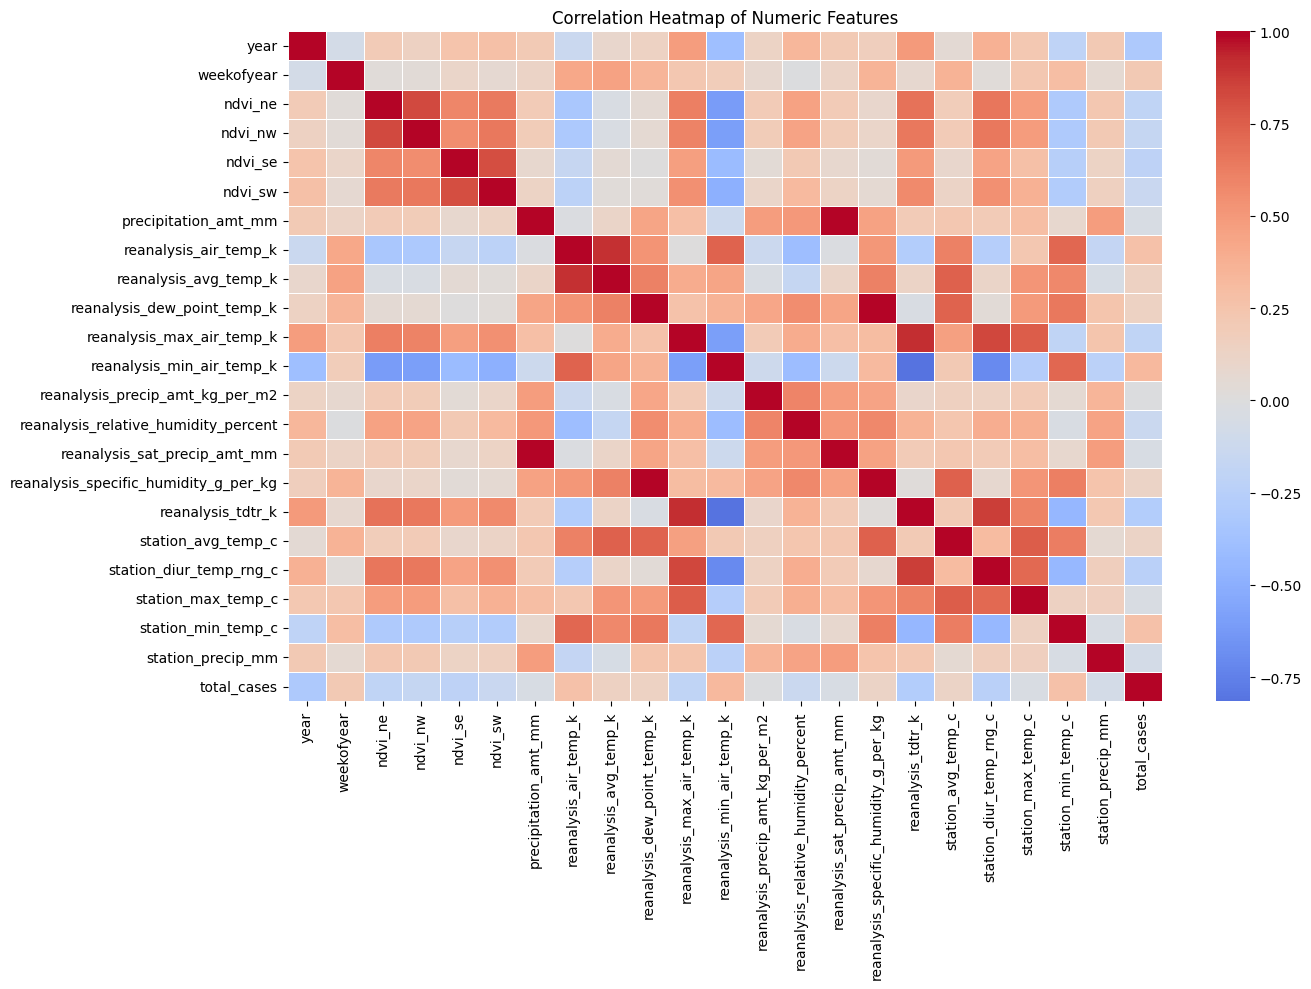

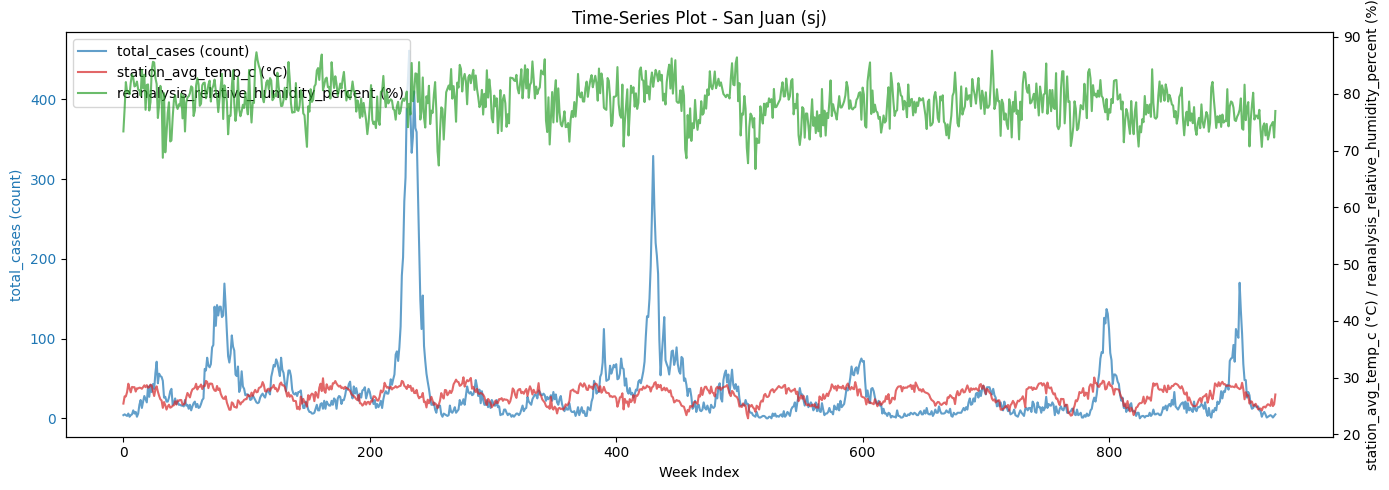

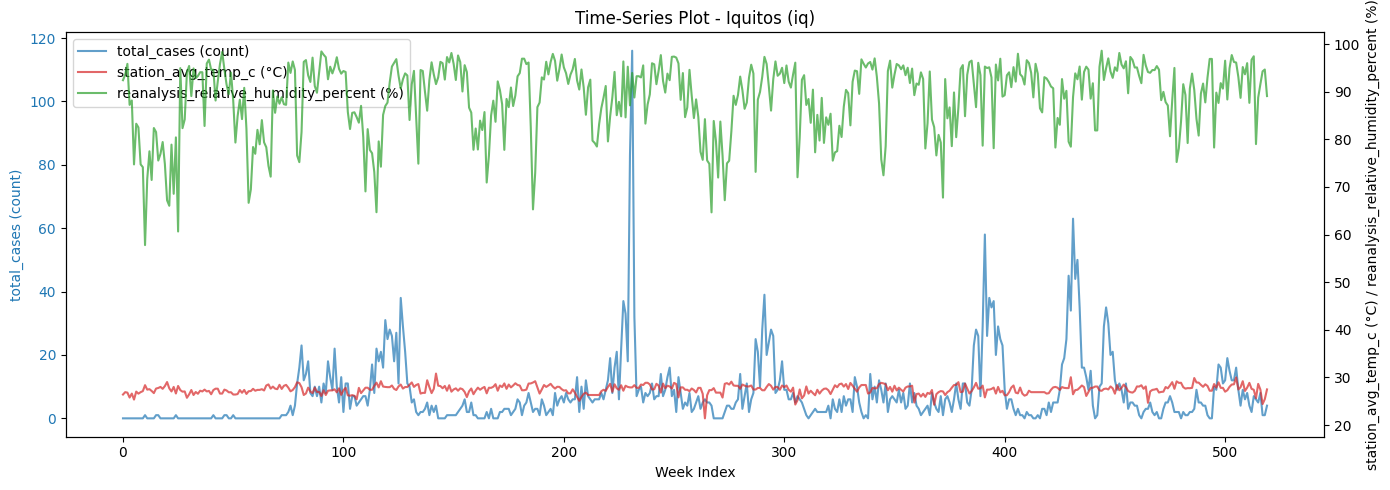

In [5]:
# --- Correlation Heatmap ---
plt.figure(figsize=(14, 10))
corr_matrix = df_train_merged.select_dtypes('number').corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

# --- Time-Series Plots per City ---
cities = {'sj': 'San Juan (sj)', 'iq': 'Iquitos (iq)'}

for city_code, city_label in cities.items():
    df_city = df_train_merged[df_train_merged['city'] == city_code].reset_index(drop=True)
    
    fig, ax1 = plt.subplots(figsize=(14, 5))
    
    # Plot total_cases on primary y-axis
    color_cases = 'tab:blue'
    ax1.set_xlabel('Week Index')
    ax1.set_ylabel('total_cases (count)', color=color_cases)
    ax1.plot(df_city.index, df_city['total_cases'], color=color_cases, alpha=0.7, label='total_cases (count)')
    ax1.tick_params(axis='y', labelcolor=color_cases)
    
    # Create shared x-axis with secondary y-axis for temperature and humidity
    ax2 = ax1.twinx()
    color_temp = 'tab:red'
    color_humidity = 'tab:green'
    ax2.set_ylabel('station_avg_temp_c (°C) / reanalysis_relative_humidity_percent (%)')
    ax2.plot(df_city.index, df_city['station_avg_temp_c'], color=color_temp, alpha=0.7, label='station_avg_temp_c (°C)')
    ax2.plot(df_city.index, df_city['reanalysis_relative_humidity_percent'], color=color_humidity, alpha=0.7, label='reanalysis_relative_humidity_percent (%)')
    ax2.tick_params(axis='y')
    
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.title(f'Time-Series Plot - {city_label}')
    fig.tight_layout()
    plt.show()

## Preprocessing and Feature Engineering

This section encodes categorical features, removes non-predictive columns, splits data into training and validation sets (80/20), and applies MinMaxScaler normalization to ensure all features are on a consistent scale for the neural network.

In [6]:
# --- Step 1: Encode city column ---
city_encoding = {'sj': 0, 'iq': 1}
df_train_merged['city'] = df_train_merged['city'].map(city_encoding)
df_test['city'] = df_test['city'].map(city_encoding)
print(f'Shape after city encoding: {df_train_merged.shape}')

# --- Step 2: Drop week_start_date column ---
df_train_merged = df_train_merged.drop(columns=['week_start_date'])
df_test = df_test.drop(columns=['week_start_date'])
print(f'Shape after dropping week_start_date: {df_train_merged.shape}')

# --- Step 3: Separate features (X) and target (y) ---
feature_cols = [col for col in df_train_merged.columns if col != 'total_cases']
X = df_train_merged[feature_cols]
y = df_train_merged['total_cases']
print(f'Features (X) shape: {X.shape}, Target (y) shape: {y.shape}')
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

# --- Step 4: Train/test split (80/20) ---
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'X_train_raw shape: {X_train_raw.shape}, X_val_raw shape: {X_val_raw.shape}')
print(f'y_train shape: {y_train.shape}, y_val shape: {y_val.shape}')

# --- Store validation city metadata for per-city evaluation later ---
df_val_meta = X_val_raw[['city']].copy()

# --- Step 5: MinMaxScaler normalization ---
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
print(f'X_train scaled shape: {X_train.shape}')
print(f'X_val scaled shape: {X_val.shape}')

# --- Step 6: City filter helper function ---
def filter_by_city(df, city_code):
    """Returns rows where encoded city == city_code (0=sj, 1=iq)."""
    return df[df['city'] == city_code]

print('\nPreprocessing complete.')

Shape after city encoding: (1456, 25)
Shape after dropping week_start_date: (1456, 24)
Features (X) shape: (1456, 23), Target (y) shape: (1456,)
Feature columns (23): ['city', 'year', 'weekofyear', 'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k', 'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k', 'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k', 'reanalysis_precip_amt_kg_per_m2', 'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm', 'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k', 'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c', 'station_min_temp_c', 'station_precip_mm']
X_train_raw shape: (1164, 23), X_val_raw shape: (292, 23)
y_train shape: (1164,), y_val shape: (292,)
X_train scaled shape: (1164, 23)
X_val scaled shape: (292, 23)

Preprocessing complete.


## ANN Model Architecture

This section defines the feedforward Artificial Neural Network using TensorFlow/Keras Sequential API. The architecture consists of multiple hidden Dense layers with ReLU activation and Dropout regularization, compiled with Adam optimizer and MSE loss for regression.

In [7]:
# Set reproducibility seeds before model instantiation
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Build the ANN model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')
])

# Compile with Adam optimizer and MSE loss
model.compile(optimizer='adam', loss='mse')

# Print model summary
model.summary()

C:\Users\Owner\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,441 (52.50 KB)

 Trainable params: 13,441 (52.50 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

This section trains the ANN model using early stopping to prevent overfitting. Training is configured with a maximum of 200 epochs, batch size of 32, and an EarlyStopping callback that monitors validation loss with patience of 10 epochs.

Epoch 1/200



 1/30 ━━━━━━━━━━━━━━━━━━━━ 17s 605ms/step - loss: 1974.3253


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2097.5237 - val_loss: 1168.9349


Epoch 2/200



 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1560.1465

...


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1392.5709 - val_loss: 915.5335


Epoch 25/200



 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 894.9931


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1347.4595 - val_loss: 917.6237


Early stopping triggered at epoch 25


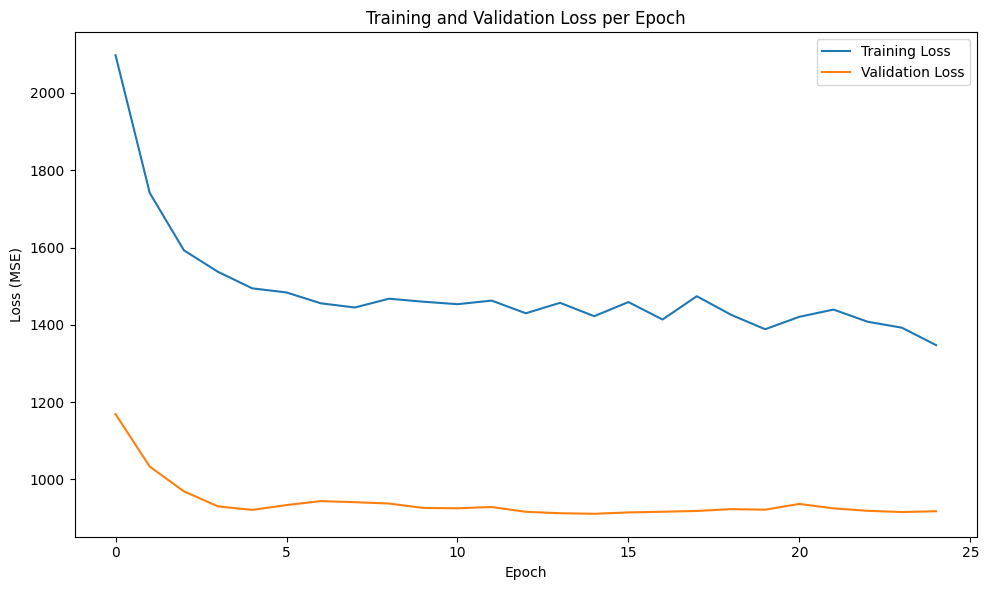

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

# Configure EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping]
)

# Print early stopping information
num_epochs_trained = len(history.history['loss'])
if num_epochs_trained < 200:
    print(f'Early stopping triggered at epoch {num_epochs_trained}')
else:
    print('Training completed all 200 epochs')

# Plot training and validation loss curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.tight_layout()
plt.show()

## Model Evaluation

This section evaluates the trained model on the validation set by computing MAE and RMSE metrics, producing a scatter plot of actual vs. predicted values, and breaking down performance by city.


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


MAE: 22.9294
RMSE: 51.2738


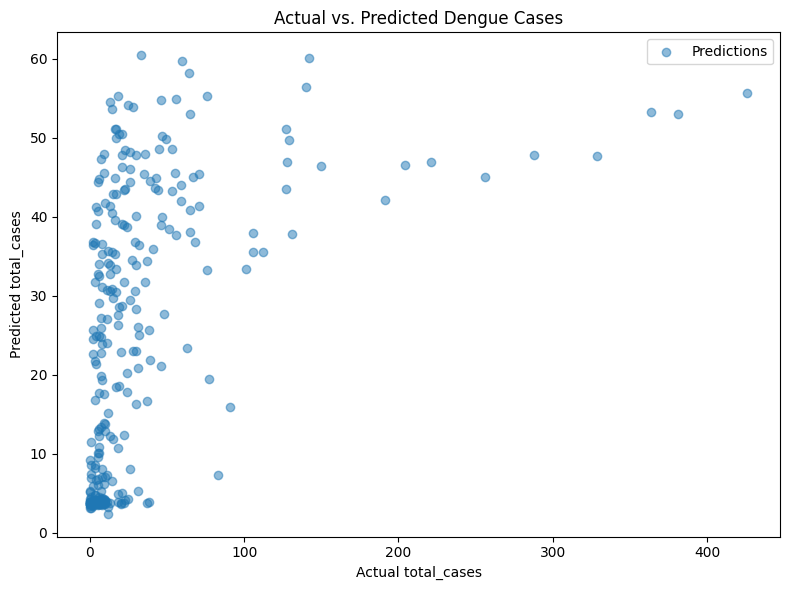


SJ - MAE: 32.6642, RMSE: 63.7156

IQ - MAE: 5.8476, RMSE: 10.8884

Combined - MAE: 22.9294, RMSE: 51.2738


In [9]:
# --- Overall Evaluation Metrics ---
y_pred = model.predict(X_val).flatten()

MAE = mean_absolute_error(y_val, y_pred)
RMSE = sqrt(mean_squared_error(y_val, y_pred))

print(f'MAE: {MAE:.4f}')
print(f'RMSE: {RMSE:.4f}')

# --- Scatter Plot: Actual vs. Predicted ---
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, alpha=0.5, label='Predictions')
plt.xlabel('Actual total_cases')
plt.ylabel('Predicted total_cases')
plt.title('Actual vs. Predicted Dengue Cases')
plt.legend()
plt.tight_layout()
plt.show()

# --- Per-City Evaluation ---
# city encoding: 0 = sj, 1 = iq
city_names = {0: 'sj', 1: 'iq'}

for city_code, city_name in city_names.items():
    mask = df_val_meta['city'].values == city_code
    y_val_city = y_val.values[mask]
    y_pred_city = y_pred[mask]
    
    city_mae = mean_absolute_error(y_val_city, y_pred_city)
    city_rmse = sqrt(mean_squared_error(y_val_city, y_pred_city))
    print(f'\n{city_name.upper()} - MAE: {city_mae:.4f}, RMSE: {city_rmse:.4f}')

# --- Combined (All rows) ---
print(f'\nCombined - MAE: {MAE:.4f}, RMSE: {RMSE:.4f}')

## Inference

This section implements the `predict_dengue_cases` function for single-row predictions and the `generate_submission` function for batch predictions on the test set, producing the final submission CSV file.

In [10]:
def predict_dengue_cases(
    input_features: dict | pd.Series,
    model: tf.keras.Model,
    scaler: MinMaxScaler,
    feature_cols: list[str]
) -> int:
    """
    Predict dengue case count for a single input row.

    Parameters
    ----------
    input_features : dict or pd.Series
        Input feature values keyed by column name.
    model : tf.keras.Model
        Trained Keras model.
    scaler : MinMaxScaler
        Fitted scaler used during training.
    feature_cols : list[str]
        Ordered list of feature column names expected by the model.

    Returns
    -------
    int
        Predicted dengue case count (non-negative integer).

    Raises
    ------
    ValueError
        If any feature columns are missing or contain null values.
    """
    # 1. Convert input to Series if dict
    if isinstance(input_features, dict):
        input_features = pd.Series(input_features)

    # 2. Validate: check all feature_cols present and non-null
    missing_cols = []
    for col in feature_cols:
        if col not in input_features.index:
            missing_cols.append(col)
        elif pd.isna(input_features[col]):
            missing_cols.append(col)
    if missing_cols:
        raise ValueError(f"Missing values in columns: {missing_cols}")

    # 3. Extract values in feature_cols order, reshape to (1, n_features)
    input_array = np.array([input_features[col] for col in feature_cols]).reshape(1, -1)

    # 4. Apply scaler.transform()
    scaled_input = scaler.transform(input_array)

    # 5. Predict
    raw_pred = model.predict(scaled_input)

    # 6. Return non-negative integer
    return int(round(max(0.0, raw_pred[0][0])))


# --- Demo: predict on one representative validation sample ---
sample_row = X_val_raw.iloc[0]
predicted_cases = predict_dengue_cases(sample_row, model, scaler, feature_cols)
actual_cases = y_val.iloc[0]
print(f'Sample prediction: {predicted_cases} cases (actual: {actual_cases})')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


Sample prediction: 45 cases (actual: 43)


C:\Users\Owner\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [11]:
def generate_submission(
    df_test: pd.DataFrame,
    model: tf.keras.Model,
    scaler: MinMaxScaler,
    feature_cols: list[str],
    output_path: str = 'submission.csv'
) -> pd.DataFrame:
    """
    Generate submission CSV by predicting dengue cases for each test row.

    Parameters
    ----------
    df_test : pd.DataFrame
        Preprocessed test DataFrame (city encoded as 0/1, week_start_date dropped).
    model : tf.keras.Model
        Trained Keras model.
    scaler : MinMaxScaler
        Fitted scaler used during training.
    feature_cols : list[str]
        Ordered list of feature column names expected by the model.
    output_path : str
        Path to write the submission CSV file.

    Returns
    -------
    pd.DataFrame
        Submission DataFrame with columns: city, year, weekofyear, total_cases.
    """
    # Map encoded city back to string for CSV output
    city_decode = {0: 'sj', 1: 'iq'}

    results = []
    for idx, row in df_test.iterrows():
        predicted_cases = predict_dengue_cases(row, model, scaler, feature_cols)
        results.append({
            'city': city_decode[int(row['city'])],
            'year': int(row['year']),
            'weekofyear': int(row['weekofyear']),
            'total_cases': predicted_cases
        })

    df_submission_out = pd.DataFrame(results)

    # Write CSV without index
    df_submission_out.to_csv(output_path, index=False)

    print(f'Submission CSV written to: {output_path}')
    print(f'Submission shape: {df_submission_out.shape}')

    return df_submission_out


# Generate the submission file
df_submission_result = generate_submission(df_test, model, scaler, feature_cols)
print(f'\nFirst 5 rows of submission:')
print(df_submission_result.head())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


Submission CSV written to: submission.csv


Submission shape: (416, 4)

First 5 rows of submission:


  city  year  weekofyear  total_cases
0   sj  2008          18           14
1   sj  2008          19           17
2   sj  2008          20           20
3   sj  2008          21           21
4   sj  2008          22           23


C:\Users\Owner\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Owner\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
print(f'MAE yang dilaporkan: {MAE:.4f}')
print(f'RMSE yang dilaporkan: {RMSE:.4f}')

report.md berhasil ditulis ke direktori proyek.
MAE yang dilaporkan: 22.9294
RMSE yang dilaporkan: 51.2738
